# Topic 08 Neural ODE: Supplementary Interactive Material

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
!pip install torchdiffeq

import torch
import torch.nn as nn
from torchdiffeq import odeint
import matplotlib.pyplot as plt




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


## Resnets as Forward Euler Processes

Each Resnet layer has the form: $$h_{i+1} = h_{i} + f(h_i;\theta_i)$$ This is like a forward euler step with a fixed step size!

Given a continuous function $f(h(t);\theta)$ we aim instead to learn a continuous mapping $f(h(t);\theta)$ so that:

$$ h(T) = h(0) + \int_{0}^{T} f(h(t);\theta)dt$$

ODE-Nets aim to learn a parameterized approximation of this $f$

## Recalling Forward Euler

In [2]:
def spiral(z):
    """ z = [x, y] """
    x, y = z
    dxdt = -y
    dydt = x
    return np.array([dxdt, dydt])


In [3]:
def forward_euler(f, z0, dt, N):
    zs = [z0]
    z = z0.copy()
    for _ in range(N):
        z = z + dt * f(z)
        zs.append(z.copy())
    return np.array(zs)


In [4]:
def exact_solution(z0, t):
    x0, y0 = z0
    theta = t
    x = x0 * np.cos(theta) - y0 * np.sin(theta)
    y = x0 * np.sin(theta) + y0 * np.cos(theta)
    return np.stack([x, y], axis=-1)


In [5]:
z0 = np.array([1.0, 0.0])
dt = 0.1
N = 100
t = np.linspace(0, dt*N, N+1)

euler_traj = forward_euler(spiral, z0, dt, N)
exact_traj = exact_solution(z0, t)


In [6]:
fig, ax = plt.subplots(figsize=(5,5))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.grid(True)
ax.set_title("Spiral ODE: Euler vs Exact")

euler_line, = ax.plot([], [], 'ro-', label='Forward Euler')
exact_line, = ax.plot([], [], 'b--', label='Exact Solution')
ax.legend()

def update(frame):
    euler_line.set_data(euler_traj[:frame,0], euler_traj[:frame,1])
    exact_line.set_data(exact_traj[:frame,0], exact_traj[:frame,1])
    return euler_line, exact_line

ani = FuncAnimation(fig, update, frames=N+1, interval=50, blit=True)
plt.close(fig)  
HTML(ani.to_jshtml())


# Neural ODE

### Learning a Vector Field with a Neural ODE

Our goal is to fit a neural network $f_\theta(z)$ such that, for any point  
$z = (x,y)$ in phase space, the network returns the **orientation of the
corresponding vector** that is, the instantaneous direction of motion defined by
the underlying differential equation.

In the Neural ODE framework, we treat this neural network as the right-hand side
of an ODE and fit it so that the **trajectories produced by integrating**

$$
\dot{z}(t) = f_\theta(z(t))
$$

**match observed trajectories** from the true system.

While in practice the *adjoint state method* offers the most memory-efficient and
sometimes the most stable way to compute gradients through the ODE solver, it is
not uncommon, to make the
following simplification:

> **Instead of integrating the adjoint equations backward in time,  
> we simply backpropagate directly through the numerical ODE solver.**

In practice, this means simply store all of the intermediate states of the solver, i.e the full trajectory.

This removes the need to implement the adjoint dynamics entirely and relies on
standard automatic differentiation. Although this uses more memory (because the
solver’s intermediate states must be stored), it keeps the implementation simple
and is perfectly suitable for low-dimensional systems and short time horizons.



Suppose we have some vector field, unknown to us at the point of training.

Epoch 0: loss = 7.007831
Epoch 5: loss = 5.427532
Epoch 10: loss = 2.810519
Epoch 15: loss = 3.668837
Epoch 20: loss = 3.016406
Epoch 25: loss = 2.603414
Epoch 30: loss = 2.126489
Epoch 35: loss = 2.014888
Epoch 40: loss = 1.349800
Epoch 45: loss = 1.070454
Epoch 50: loss = 1.648783
Epoch 55: loss = 1.864560
Epoch 60: loss = 1.067481
Epoch 65: loss = 1.565568
Epoch 70: loss = 1.136342
Epoch 75: loss = 1.771010
Epoch 80: loss = 1.046661
Epoch 85: loss = 1.394718
Epoch 90: loss = 0.847550
Epoch 95: loss = 1.034735
Epoch 100: loss = 1.358470
Epoch 105: loss = 0.581156
Epoch 110: loss = 0.605913
Epoch 115: loss = 0.442808
Epoch 120: loss = 0.734294
Epoch 125: loss = 0.508747
Epoch 130: loss = 0.453029
Epoch 135: loss = 0.152948
Epoch 140: loss = 0.519816
Epoch 145: loss = 0.133943
Epoch 150: loss = 0.219983
Epoch 155: loss = 0.130804
Epoch 160: loss = 0.135207
Epoch 165: loss = 0.064222
Epoch 170: loss = 0.188010
Epoch 175: loss = 0.137863
Epoch 180: loss = 0.024093
Epoch 185: loss = 0.260

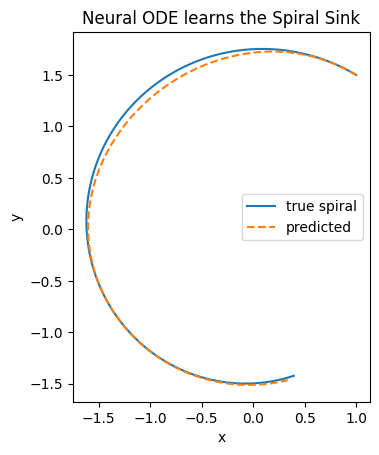

In [8]:
# -----------------------------
# 1. True spiral sink ODE
# -----------------------------
def true_spiral(t, z, alpha=0.1, omega=2.0):
    x, y = z[...,0], z[...,1]
    dx = -alpha * x - omega * y
    dy =  omega * x - alpha * y
    return torch.stack([dx, dy], -1)

# time window
t_eval = torch.linspace(0, 2.0, 200)

# -----------------------------
# 2. Neural ODE vector field
# -----------------------------
class VectorField(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2)
        )

    def forward(self, t, z):
        return self.net(z)

f = VectorField()

# -----------------------------
# 3. Optimizer
# -----------------------------
optimizer = torch.optim.Adam(f.parameters(), lr=5e-3)

# -----------------------------
# 4. Training data
# -----------------------------
def sample_initial_conditions(n):
    # sample radius 0–2 in any direction
    radius = 2.0 * torch.randn(n,2)
    return radius

num_inits = 50
epochs = 200

# -----------------------------
# 5. Training loop
# -----------------------------
for epoch in range(epochs):
    optimizer.zero_grad()
    
    x0s = sample_initial_conditions(num_inits)

    loss = 0.0
    for x0 in x0s:
        true_traj = odeint(lambda t, z: true_spiral(t,z), x0, t_eval)
        pred_traj = odeint(f, x0, t_eval)
        loss += ((pred_traj - true_traj)**2).mean()

    loss /= num_inits
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.6f}")




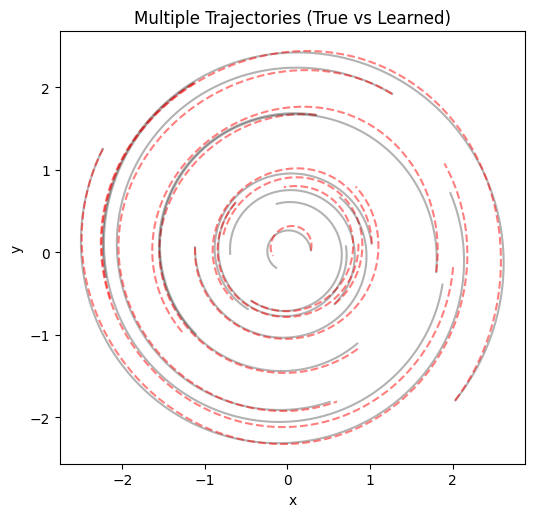

In [9]:
plt.figure(figsize=(6,6))

for _ in range(12):
    x0 = torch.randn(2)
    true_traj = odeint(lambda t,z: true_spiral(t,z), x0, t_eval)
    pred_traj = odeint(f, x0, t_eval).detach()

    plt.plot(true_traj[:,0], true_traj[:,1], 'k', alpha=0.3)
    plt.plot(pred_traj[:,0], pred_traj[:,1], 'r--', alpha=0.5)

plt.title("Multiple Trajectories (True vs Learned)")
plt.xlabel("x"); plt.ylabel("y")
plt.gca().set_aspect('equal')
plt.show()


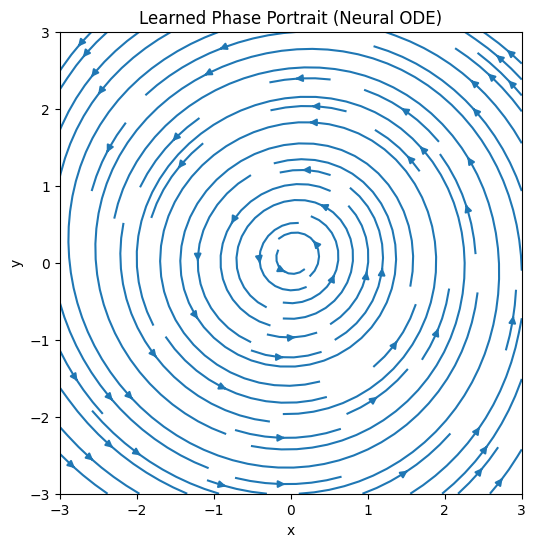

In [11]:
# grid
x = torch.linspace(-3, 3, 40)
y = torch.linspace(-3, 3, 40)
X, Y = torch.meshgrid(x, y, indexing="xy")

# compute derivatives
U = -alpha*X - omega*Y
V =  omega*X - alpha*Y


with torch.no_grad():
    grid = torch.stack([X, Y], dim=-1)  # shape (40,40,2)
    F = f(None, grid)                   # (40,40,2)
    U = F[...,0]
    V = F[...,1]

plt.figure(figsize=(6,6))
plt.streamplot(X.numpy(), Y.numpy(), U.numpy(), V.numpy(), density=1.0)
plt.title("Learned Phase Portrait (Neural ODE)")
plt.xlabel("x"); plt.ylabel("y")
plt.gca().set_aspect('equal')
plt.show()
